# Cooling analysis

In [35]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.constants import k as k_B_SI

from cooling_functions import cool_Lambda, cooling_time, volumetric_cooling_rate

# Boltzmann constant in cgs: erg / K
k_B = k_B_SI * 1e7
k_B = 1.380649e-16  # erg K^-1

# seconds per Myr
Myr = 1e6 * 365.25 * 24 * 3600
pc = 3.085e18

# idealised data cube

In [28]:
# load data cube from previous tutorial
# or download it via get-data.sh in folder tmp-data

with open('../sim-data/SILCC_hdf5_plt_cnt_3000-uniform-cube-N256-full.pkl', 'rb') as handle:
    data = pickle.load(handle)

# defines for cooling time etc

In [29]:
data.keys()

dict_keys(['n', 'rho', 'T', 'f_ion', 'velx', 'magx', 'vely', 'magy', 'velz', 'magz', 'x_pc_bnds', 'x_pc', 'y_pc_bnds', 'y_pc', 'z_pc_bnds', 'z_pc'])

In [31]:
def cooling_time(n, T, H, mu_factor=1.5):
    """
    Cooling time:
        t_cool = e_th / H

    For ideal gas:
        e_th = 3/2 n k_B T

    H must be volumetric cooling rate n^2 Lambda(T).
    """
    eth = mu_factor * n * k_B * T
    return eth / H


def print_stats(name, x):
    x = np.asarray(x)
    x = x[np.isfinite(x)]

    p16, p50, p84 = np.percentile(x, [16, 50, 84])

    print(f"{name}")
    print("-" * len(name))
    print(f"mean   = {np.mean(x):.6e}")
    print(f"std    = {np.std(x):.6e}")
    print(f"p16    = {p16:.6e}")
    print(f"median = {p50:.6e}")
    print(f"p84    = {p84:.6e}")
    print()


def plot_cooling_time_histogram(tcool, unit="Myr", bins=100):
    """
    Histogram of cooling time.
    """

    if unit == "yr":
        fac = 1.0 / (3600 * 24 * 365.25)
    elif unit == "Myr":
        fac = 1.0 / (1e6 * 3600 * 24 * 365.25)
    else:
        fac = 1.0

    x = tcool[np.isfinite(tcool) & (tcool > 0)] * fac

    plt.figure(figsize=(7, 5))
    plt.hist(np.log10(x), bins=bins, histtype="step", linewidth=2)
    plt.xlabel(rf"$\log_{{10}}(t_\mathrm{{cool}} / {unit})$")
    plt.ylabel("Number of cells")
    plt.tight_layout()
    plt.show()

def plot_density_histogram(n, unit="g/cc", bins=100):
    """
    Histogram of density time.
    """
    plt.figure(figsize=(7, 5))
    plt.hist(np.log10(x), bins=bins, histtype="step", linewidth=2)
    plt.xlabel(rf"$\log_{{10}}(\rho) / {unit})$")
    plt.ylabel("Number of cells")
    plt.tight_layout()
    plt.show()
    
def cooling_rate_cell(n, T, cool_Lambda):
    """
    Volumetric cooling rate:
        H = n^2 Lambda(T)   [erg cm^-3 s^-1]
    """
    n = np.asarray(n)
    T = np.asarray(T)

    Lambda = cool_Lambda(T)
    #Lambda = np.vectorize(cool_Lambda)(T)
    return n**2 * Lambda


def cooling_rate_of_mean_gas(n, T, cool_Lambda):
    """
    Cooling rate evaluated at mean density and mean temperature.
    """
    n_mean = np.mean(n)
    T_mean = np.mean(T)
    return n_mean**2 * cool_Lambda(T_mean)


def cooling_clumping_factor(n, T, cool_Lambda, mask=None):
    """
    C_cool = <n^2 Lambda(T)> / (<n>^2 Lambda(<T>))
    """
    if mask is None:
        mask = np.ones_like(n, dtype=bool)

    n_sel = n[mask]
    T_sel = T[mask]

    H_cells = cooling_rate_cell(n_sel, T_sel, cool_Lambda)
    H_mean = cooling_rate_of_mean_gas(n_sel, T_sel, cool_Lambda)

    return np.mean(H_cells) / H_mean


def temperature_phase_masks(T):
    """
    Example ISM temperature phases.
    Adjust limits if needed.
    """
    return {
        "cold": T < 300.0,
        "warm": (T >= 300.0) & (T < 3.0e4),
        "hot": T >= 3.0e4,
    }


def analyse_cooling_cube(n, T, cool_Lambda, bins=100, plot=True):
    """
    Compute cooling rate, print diagnostics, phase-wise C_cool,
    and optionally plot histogram.
    """

    H = cooling_rate_cell(n, T, cool_Lambda)

    H_mean_cells = np.mean(H)
    H_mean_gas = cooling_rate_of_mean_gas(n, T, cool_Lambda)
    C_cool = H_mean_cells / H_mean_gas

    print("Global cooling diagnostics")
    print("--------------------------")
    print(f"<n>                  = {np.mean(n):.6e} cm^-3")
    print(f"<T>                  = {np.mean(T):.6e} K")
    print(f"<n^2 Lambda(T)>      = {H_mean_cells:.6e} erg cm^-3 s^-1")
    print(f"<n>^2 Lambda(<T>)    = {H_mean_gas:.6e} erg cm^-3 s^-1")
    print(f"C_cool               = {C_cool:.6e}")
    print()

    print("Temperature phases")
    print("------------------")

    phase_results = {}

    for name, mask in temperature_phase_masks(T).items():
        if np.any(mask):
            C_phase = cooling_clumping_factor(n, T, cool_Lambda, mask=mask)
            H_phase = np.mean(H[mask])

            phase_results[name] = {
                "mask": mask,
                "volume_fraction": np.mean(mask),
                "mean_n": np.mean(n[mask]),
                "mean_T": np.mean(T[mask]),
                "mean_cooling": H_phase,
                "C_cool": C_phase,
            }

            print(f"{name:>6s}:")
            print(f"  volume fraction     = {np.mean(mask):.6e}")
            print(f"  <n>                 = {np.mean(n[mask]):.6e} cm^-3")
            print(f"  <T>                 = {np.mean(T[mask]):.6e} K")
            print(f"  <cooling>           = {H_phase:.6e} erg cm^-3 s^-1")
            print(f"  C_cool              = {C_phase:.6e}")
        else:
            print(f"{name:>6s}: no cells")

    if plot:
        plot_cooling_histogram(H, bins=bins)

    return H, {
        "mean_cell_cooling": H_mean_cells,
        "cooling_of_mean_gas": H_mean_gas,
        "C_cool": C_cool,
        "phases": phase_results,
    }


def plot_cooling_histogram(H, bins=100):
    """
    Histogram of volumetric cooling rate.
    """
    Hpos = H[H > 0]

    plt.figure(figsize=(7, 5))
    plt.hist(np.log10(Hpos), bins=bins, histtype="step", linewidth=2)
    plt.xlabel(r"$\log_{10}(\mathcal{L})$  [erg cm$^{-3}$ s$^{-1}$]")
    plt.ylabel("Number of cells")
    plt.title("Cooling-rate histogram")
    plt.tight_layout()
    plt.show()

def analyse_cooling_and_time(n, T, cool_Lambda, bins=100):
    H = cooling_rate_cell(n, T, cool_Lambda)
    tcool = cooling_time(n, T, H)

    print_stats("Cooling rate [erg cm^-3 s^-1]", H)
    print_stats("Cooling time [s]", tcool)

    plot_cooling_histogram(H, bins=bins)
    plot_cooling_time_histogram(tcool, unit="Myr", bins=bins)
    plot_density_histogram(n*1.4*1.67e-24)
    
    return H, tcool


# subblock analysis

In [4]:
def block_view_mean(a, block_size):
    """
    Average a 3D cube over cubic sub-volumes of size block_size^3.
    """
    N = a.shape[0]
    assert a.shape == (N, N, N)
    assert N % block_size == 0

    nblock = N // block_size

    result = a.reshape(
        nblock, block_size,
        nblock, block_size,
        nblock, block_size
    ).mean(axis=(1, 3, 5))
    print("subblock shape: ", result.shape)
    return result


def subvolume_cooling_analysis(n, T, cool_Lambda, min_blocks=1, verbose=True, plot=True, extent=None):
    """
    Go from the full resolution down to coarse sub-volumes.

    block_size = number of original cells per sub-volume side.
    nsub       = number of sub-volumes per dimension.
    """

    if verbose:
        print("start subvolume_cooling_analysis")
    N = n.shape[0]
    assert n.shape == (N, N, N)
    assert T.shape == (N, N, N)
    assert (N & (N - 1)) == 0, "N must be a power of two"

    if verbose:
        print("cooling_rate_cell for all cells")
        print("cooling_time for all cells")
    H = cooling_rate_cell(n, T, cool_Lambda)
    tcool = cooling_time(n, T, H)
    if verbose:
        print("  ...done")

    results = []

    block_sizes = []
    b = 1
    while N // b >= min_blocks:
        block_sizes.append(b)
        b *= 2

    for block_size in block_sizes:
        print("subvolume analysis, blocksize:", block_size)
        nbar = block_view_mean(n, block_size)
        Tbar = block_view_mean(T, block_size)
        Hbar = block_view_mean(H, block_size)

        if extent is not None:
            res = np.round((extent[1]-extent[0])/nbar.shape[0],0)
        else:
            res = None

        if plot:
            fig, ax = plt.subplots()
            if extent is not None:
                title = "res. = "+ str( res )+" pc"
                ax.set_title(title)
            ax.imshow(np.sum(nbar,axis=2).T,norm=LogNorm(), origin="lower", extent=extent, cmap="afmhot")
            fig.savefig("test-subvolume-"+str(block_size)+".png", bbox_inches="tight")

        #H_mean_gas = nbar**2 * np.vectorize(cool_Lambda)(Tbar)
        H_mean_gas = nbar**2 * cool_Lambda(Tbar)

        Ccool = Hbar / H_mean_gas

        tcool_block = cooling_time(nbar, Tbar, Hbar)

        p16, p50, p84 = np.percentile(tcool_block[np.isfinite(tcool_block)], [16, 50, 84])

        results.append({
            "block_size": block_size,
            "resolution": res,
            "nsub": N // block_size,
            "subvolume_cells": block_size**3,
            "Ccool_mean": np.mean(Ccool),
            "Ccool_std": np.std(Ccool),
            "tcool_mean": np.mean(tcool_block),
            "tcool_std": np.std(tcool_block),
            "tcool_p16": p16,
            "tcool_median": p50,
            "tcool_p84": p84,
        })

    return results

In [20]:
def plot_subvolume_results(results, time_unit="Myr"):
    block_size = np.array([r["block_size"] for r in results])
    nsub = np.array([r["nsub"] for r in results])

    Cmean = np.array([r["Ccool_mean"] for r in results])
    Cstd = np.array([r["Ccool_std"] for r in results])

    tmean = np.array([r["tcool_mean"] for r in results])
    tp16 = np.array([r["tcool_p16"] for r in results])
    tp84 = np.array([r["tcool_p84"] for r in results])

    res = np.array([r["resolution"] for r in results])
    
    if time_unit == "Myr":
        tfac = 1.0 / (1e6 * 365.25 * 24 * 3600)
    elif time_unit == "yr":
        tfac = 1.0 / (365.25 * 24 * 3600)
    else:
        tfac = 1.0
    print(res)
    plt.figure(figsize=(7, 5))
    if res[0] is not None:
        plt.errorbar(res, Cmean, yerr=Cstd, marker="o", capsize=3)
        plt.xscale("log")
        plt.xlabel("cell size [pc]")
    else:
        plt.errorbar(block_size, Cmean, yerr=Cstd, marker="o", capsize=3)
        plt.xscale("log", base=2)
        plt.xlabel("Sub-volume side length [cells]")

    plt.yscale("log")
    plt.ylabel(r"$C_\mathrm{cool}$")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 5))
    if res[0] is not None:
        plt.plot(res, tmean * tfac, marker="o", label="mean")
        plt.xscale("log")
        plt.xlabel("resolution [pc]")
        plt.fill_between(res, tp16 * tfac, tp84 * tfac, alpha=0.3, label="16--84 percentile")
    else:
        plt.plot(block_size, tmean * tfac, marker="o", label="mean")
        plt.xscale("log", base=2)
        plt.xlabel("Sub-volume side length [cells]")
        plt.fill_between(block_size, tp16 * tfac, tp84 * tfac, alpha=0.3, label="16--84 percentile")
    plt.yscale("log")
    plt.ylabel(rf"$t_\mathrm{{cool}}$ [{time_unit}]")
    plt.legend()
    plt.tight_layout()
    plt.show()

## run cooling analysis and cooling time

Cooling rate [erg cm^-3 s^-1]
-----------------------------
mean   = 1.611040e-23
std    = 1.046044e-20
p16    = 6.999833e-29
median = 9.829498e-28
p84    = 3.445702e-26

Cooling time [s]
----------------
mean   = 5.101737e+15
std    = 1.350805e+16
p16    = 8.611717e+12
median = 2.924333e+14
p84    = 8.295621e+15



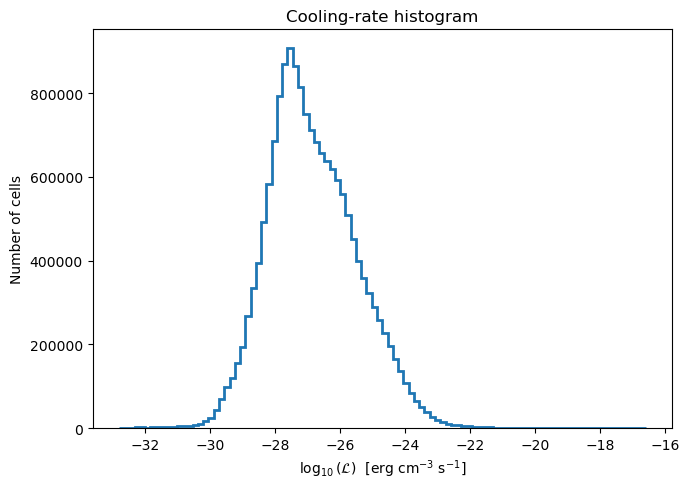

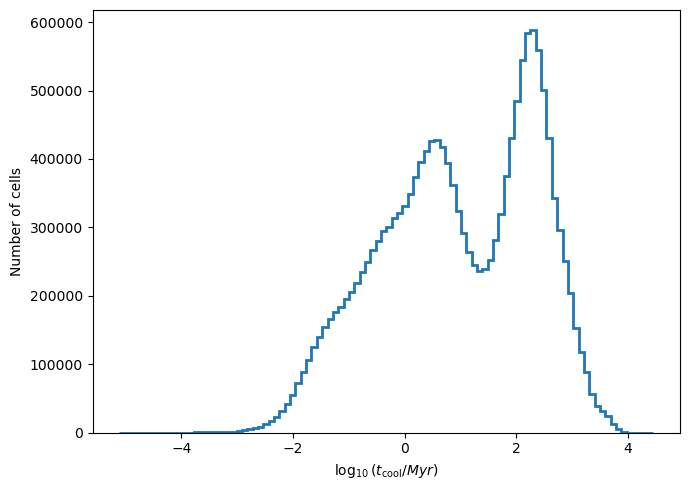

NameError: name 'x' is not defined

<Figure size 700x500 with 0 Axes>

In [32]:
H, tcool = analyse_cooling_and_time(
    n=data["n"],
    T=data["T"],
    cool_Lambda=cool_Lambda,
)

## run subvolume analysis

start subvolume_cooling_analysis
cooling_rate_cell for all cells
cooling_time for all cells
  ...done
subvolume analysis, blocksize: 1
subblock shape:  (128, 128, 128)
subblock shape:  (128, 128, 128)
subblock shape:  (128, 128, 128)
subvolume analysis, blocksize: 2
subblock shape:  (64, 64, 64)
subblock shape:  (64, 64, 64)
subblock shape:  (64, 64, 64)
subvolume analysis, blocksize: 4
subblock shape:  (32, 32, 32)
subblock shape:  (32, 32, 32)
subblock shape:  (32, 32, 32)
subvolume analysis, blocksize: 8
subblock shape:  (16, 16, 16)
subblock shape:  (16, 16, 16)
subblock shape:  (16, 16, 16)
subvolume analysis, blocksize: 16
subblock shape:  (8, 8, 8)
subblock shape:  (8, 8, 8)
subblock shape:  (8, 8, 8)
subvolume analysis, blocksize: 32
subblock shape:  (4, 4, 4)
subblock shape:  (4, 4, 4)
subblock shape:  (4, 4, 4)
subvolume analysis, blocksize: 64
subblock shape:  (2, 2, 2)
subblock shape:  (2, 2, 2)
subblock shape:  (2, 2, 2)
subvolume analysis, blocksize: 128
subblock shape:  

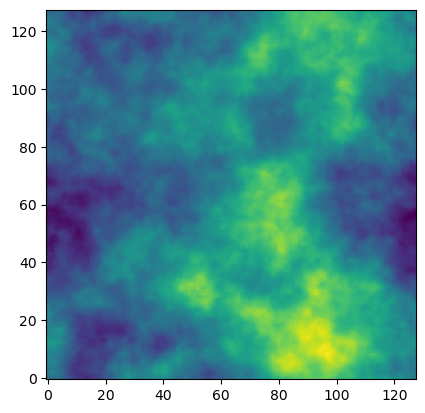

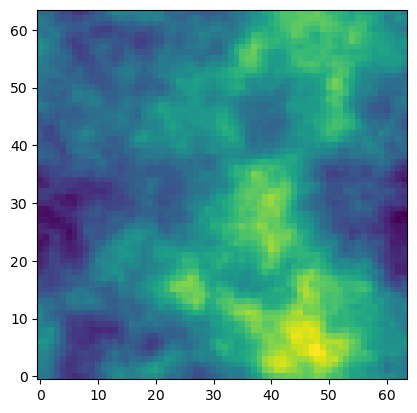

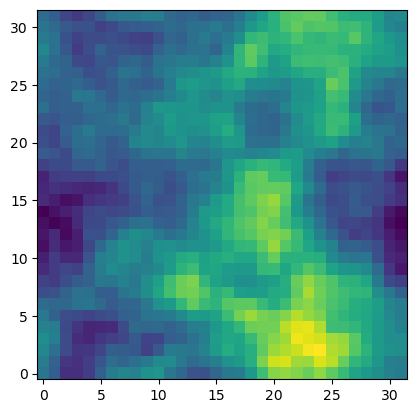

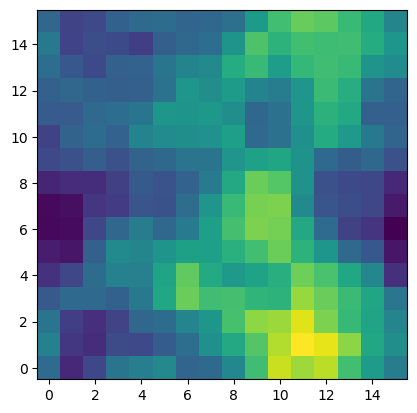

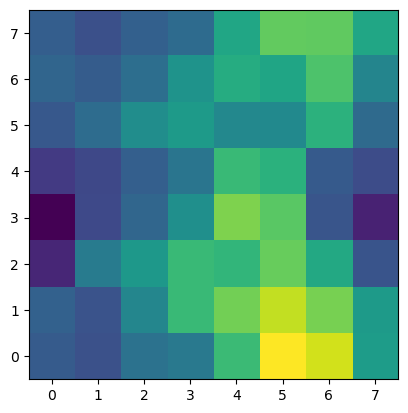

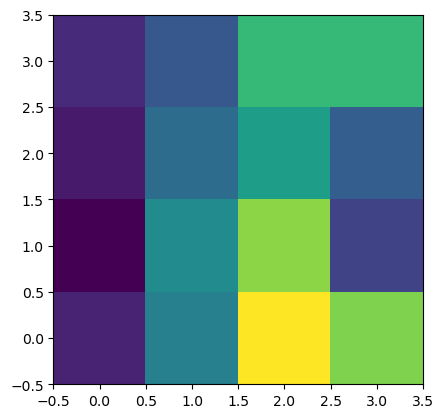

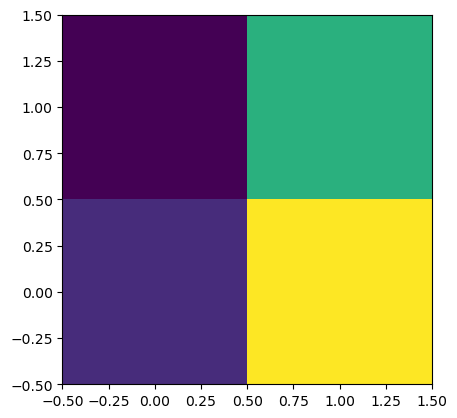

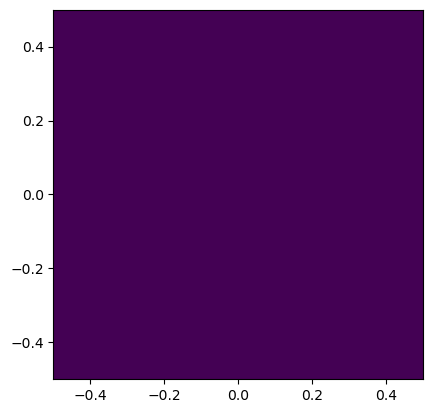

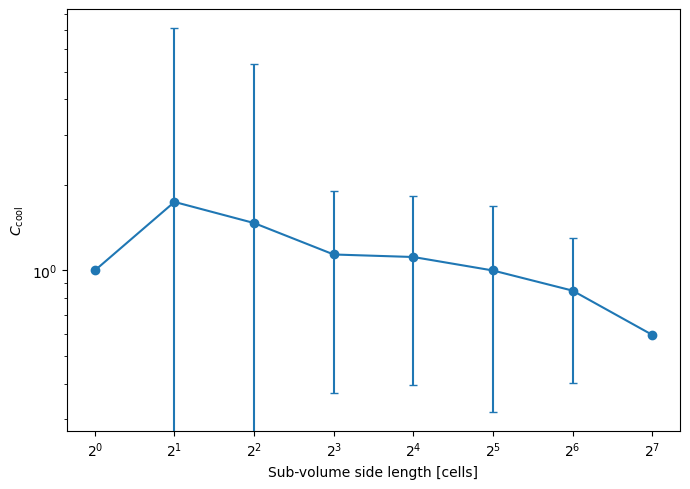

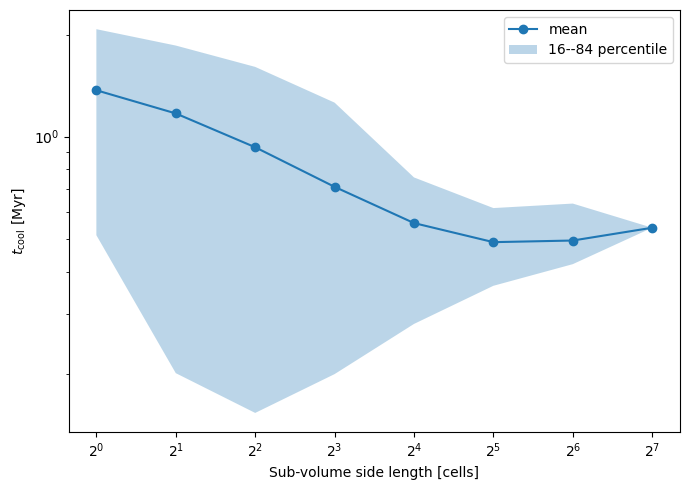

In [8]:
results = subvolume_cooling_analysis(
    n=data["n"],
    T=data["T"],
    cool_Lambda=cool_Lambda,
)

plot_subvolume_results(results, time_unit="Myr")

Global cooling diagnostics
--------------------------
<n>                  = 1.000000e+00 cm^-3
<T>                  = 9.599646e+05 K
<n^2 Lambda(T)>      = 1.169794e-23 erg cm^-3 s^-1
<n>^2 Lambda(<T>)    = 1.969743e-23 erg cm^-3 s^-1
C_cool               = 5.938815e-01

Temperature phases
------------------
  cold: no cells
  warm:
  volume fraction     = 2.948012e-01
  <n>                 = 2.271226e+00 cm^-3
  <T>                 = 6.235812e+03 K
  <cooling>           = 8.844322e-24 erg cm^-3 s^-1
  C_cool              = 4.579190e+01
   hot:
  volume fraction     = 7.051988e-01
  <n>                 = 4.685769e-01 cm^-3
  <T>                 = 1.358661e+06 K
  <cooling>           = 1.289087e-23 erg cm^-3 s^-1
  C_cool              = 3.043480e+00


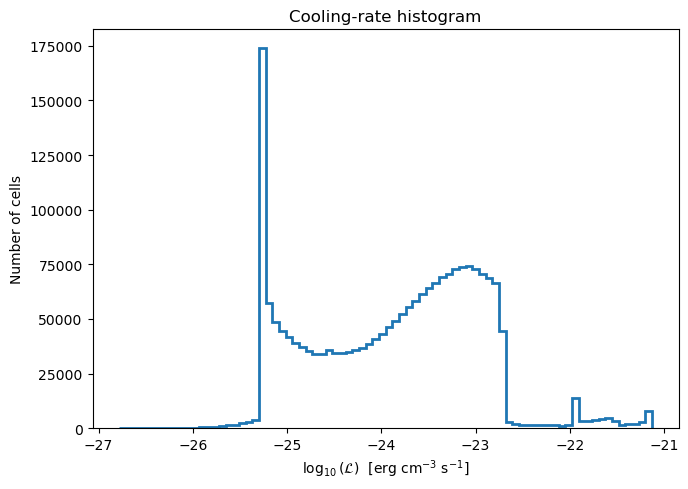

In [10]:
H, cooling_stats = analyse_cooling_cube(
    n=data["n"],
    T=data["T"],
    cool_Lambda=cool_Lambda,
    bins=80,
    plot=True,
)

# repeat with SILCC data

In [11]:
# now apply this to extracted SILCC data
# load data cube

f1 = '../sim-data/SILCC_hdf5_plt_cnt_3000-uniform-cube-N512.pkl'
f2 = '../sim-data/SILCC_hdf5_plt_cnt_3000-uniform-cube-N256-full.pkl'

with open(f2, 'rb') as handle:
    data = pickle.load(handle)


Cooling rate [erg cm^-3 s^-1]
-----------------------------
mean   = 1.611040e-23
std    = 1.046044e-20
p16    = 6.999833e-29
median = 9.829498e-28
p84    = 3.445702e-26

Cooling time [s]
----------------
mean   = 5.101737e+15
std    = 1.350805e+16
p16    = 8.611717e+12
median = 2.924333e+14
p84    = 8.295621e+15



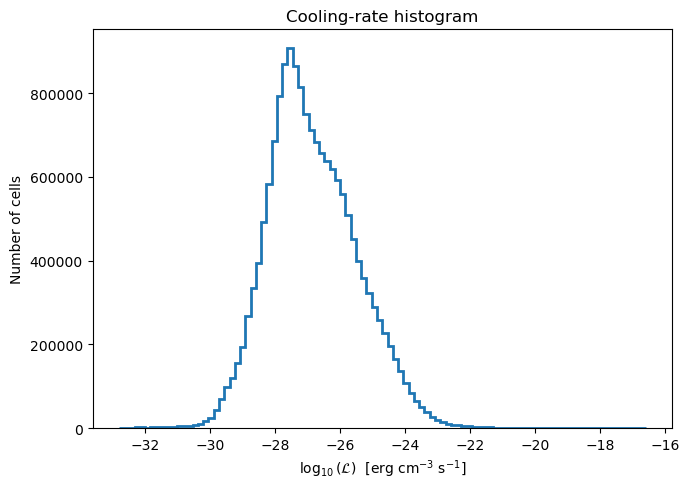

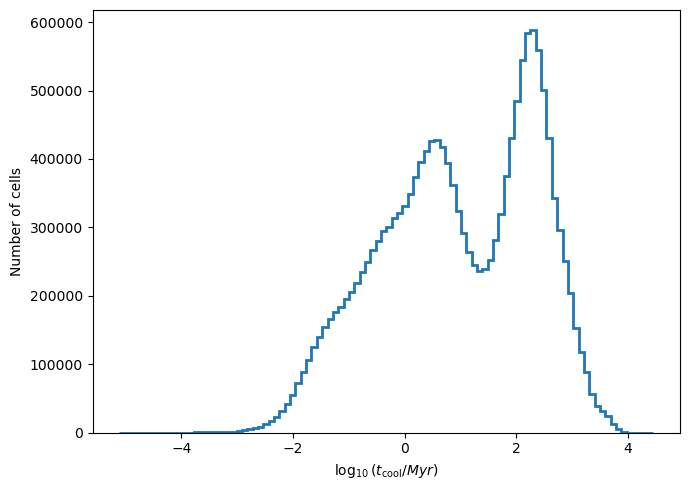

In [13]:
H, tcool = analyse_cooling_and_time(
    n=data["n"],
    T=data["T"],
    cool_Lambda=cool_Lambda,
)

start subvolume_cooling_analysis
cooling_rate_cell for all cells
cooling_time for all cells
  ...done
subvolume analysis, blocksize: 1
subblock shape:  (256, 256, 256)
subblock shape:  (256, 256, 256)
subblock shape:  (256, 256, 256)
subvolume analysis, blocksize: 2
subblock shape:  (128, 128, 128)
subblock shape:  (128, 128, 128)
subblock shape:  (128, 128, 128)
subvolume analysis, blocksize: 4
subblock shape:  (64, 64, 64)
subblock shape:  (64, 64, 64)
subblock shape:  (64, 64, 64)
subvolume analysis, blocksize: 8
subblock shape:  (32, 32, 32)
subblock shape:  (32, 32, 32)
subblock shape:  (32, 32, 32)
subvolume analysis, blocksize: 16
subblock shape:  (16, 16, 16)
subblock shape:  (16, 16, 16)
subblock shape:  (16, 16, 16)
subvolume analysis, blocksize: 32
subblock shape:  (8, 8, 8)
subblock shape:  (8, 8, 8)
subblock shape:  (8, 8, 8)
subvolume analysis, blocksize: 64
subblock shape:  (4, 4, 4)
subblock shape:  (4, 4, 4)
subblock shape:  (4, 4, 4)
subvolume analysis, blocksize: 128

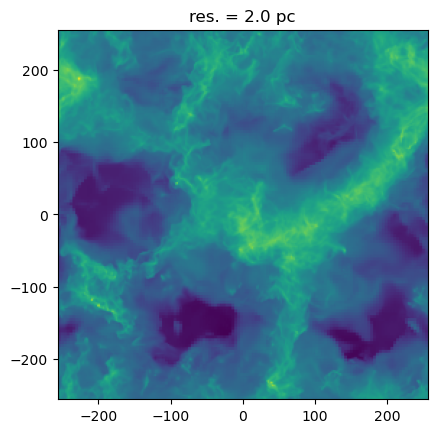

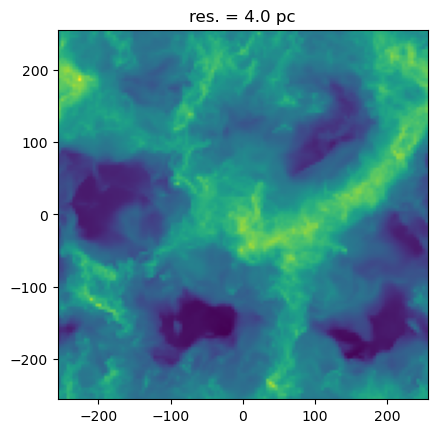

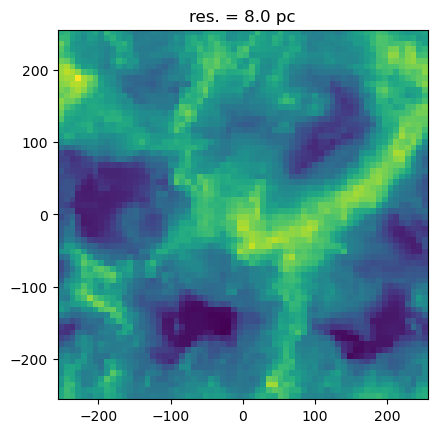

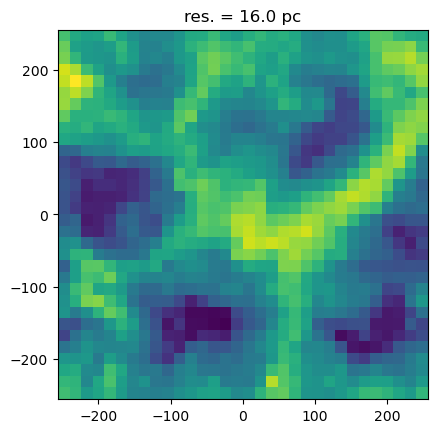

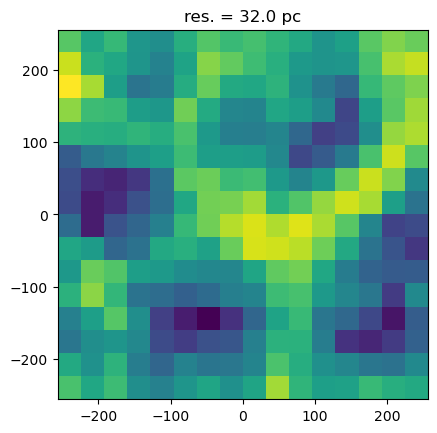

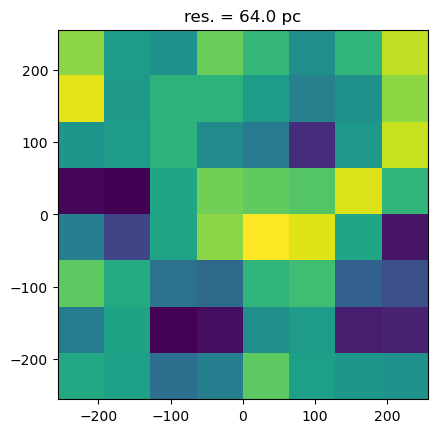

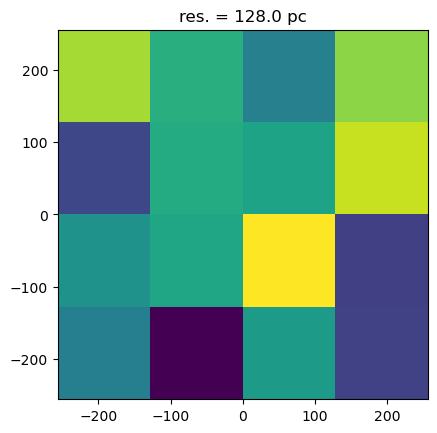

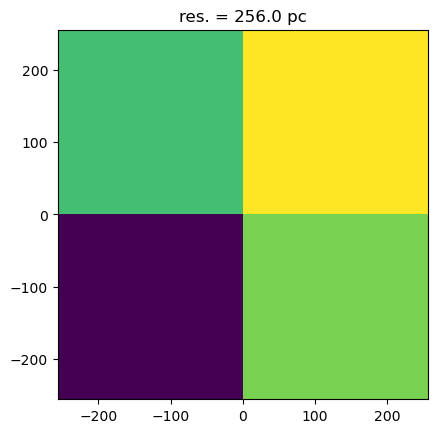

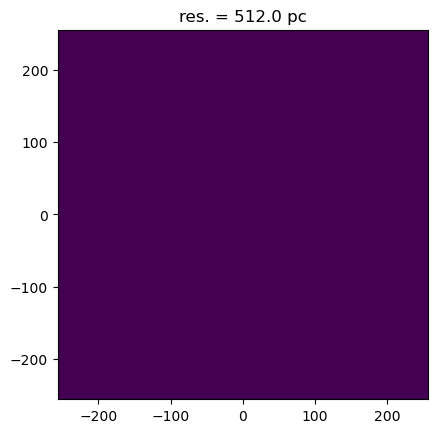

In [14]:
results = subvolume_cooling_analysis(
    n=data["n"],
    T=data["T"],
    cool_Lambda=cool_Lambda,
    extent=[-256,256,-256,256]
)

[{'block_size': 1, 'resolution': np.float64(2.0), 'nsub': 256, 'subvolume_cells': 1, 'Ccool_mean': np.float64(1.0), 'Ccool_std': np.float64(0.0), 'tcool_mean': np.float64(5101737082402561.0), 'tcool_std': np.float64(1.3508049079433646e+16), 'tcool_p16': np.float64(8611716830242.324), 'tcool_median': np.float64(292433342977404.9), 'tcool_p84': np.float64(8295620804976832.0)}, {'block_size': 2, 'resolution': np.float64(4.0), 'nsub': 128, 'subvolume_cells': 8, 'Ccool_mean': np.float64(1.8561666836624338), 'Ccool_std': np.float64(24.609294171851374), 'tcool_mean': np.float64(4935710541533694.0), 'tcool_std': np.float64(1.3322075363570026e+16), 'tcool_p16': np.float64(7110613027110.56), 'tcool_median': np.float64(230706378323552.12), 'tcool_p84': np.float64(8003743963798204.0)}, {'block_size': 4, 'resolution': np.float64(8.0), 'nsub': 64, 'subvolume_cells': 64, 'Ccool_mean': np.float64(4.967670786006148), 'Ccool_std': np.float64(105.96376872284918), 'tcool_mean': np.float64(4338421940575716

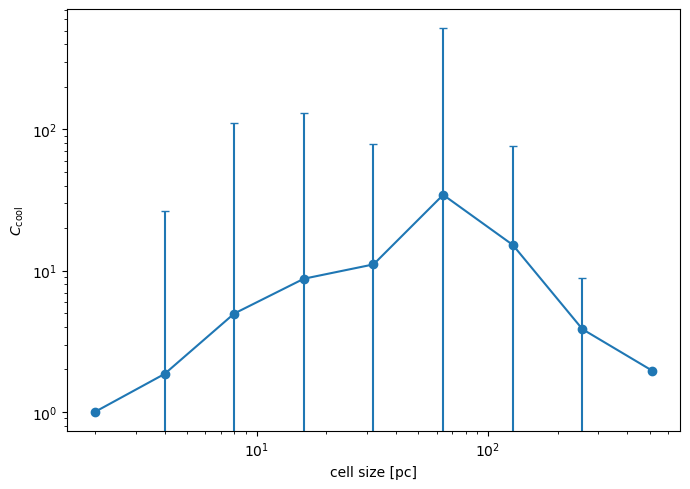

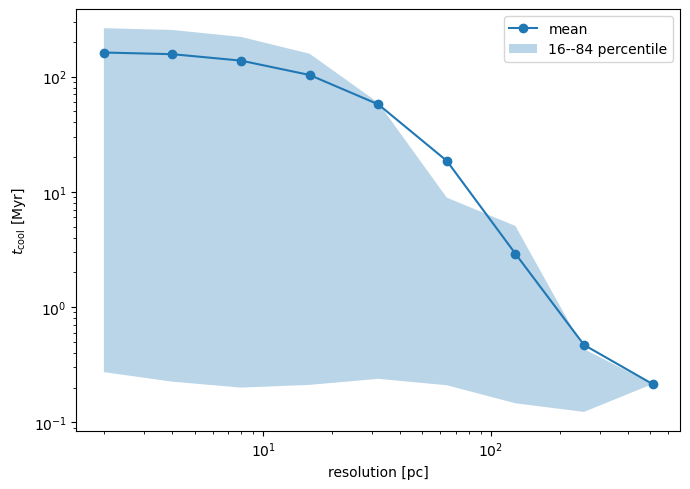

In [21]:
plot_subvolume_results(results, time_unit="Myr")

# cooling luminosity

- computation of the cooling luminosity in different phases
- alongside mass and volume fraction

In [58]:
# total cooling luminosity
V = (500.*pc)**3

H = cooling_rate_cell(data["n"], data["T"], cool_Lambda)

# separate phases
idx_all  = np.where(data["T"] > 0)
idx_cold = np.where(data["T"] < 300)
idx_warm = np.where((data["T"] > 300) & (data["T"] < 3e5))
idx_hot  = np.where(data["T"] > 3e5)

loop over all phases

In [71]:
print(f"{'Name':<25} {'Vff':>8} {'Mf':>8} {'Ltot':>12} {'Lfrac':>8}")
print("-" * 65)

Ltot = H.sum()*V
for ids, name in zip([idx_all, idx_cold, idx_warm, idx_hot], ["total", "cold", "warm", "hot"]):
    Vfrac = H[ids].size / H.size
    Mfrac = data["n"][ids].sum() / data["n"].sum()
    Lphas = H[ids].sum()*V
    Lfrac = Lphas / Ltot
    print(f"{name:<25} {Vfrac:>8.3f} {Mfrac:>8.3f}   {Lphas:>9.4e} {Lfrac:>8.3f}")

Name                           Vff       Mf         Ltot    Lfrac
-----------------------------------------------------------------
total                        1.000    1.000   9.9198e+47    1.000
cold                         0.022    0.705   3.1676e+45    0.003
warm                         0.474    0.289   8.8746e+47    0.895
hot                          0.504    0.006   1.0135e+47    0.102
